# Artificial Neural Network
Artificial Neural Network is inspitired by brain architecture. A smalles piece of neural network is a artificial neuron. First artificial neuron proposed by the McCullach and Pitt at 1943.
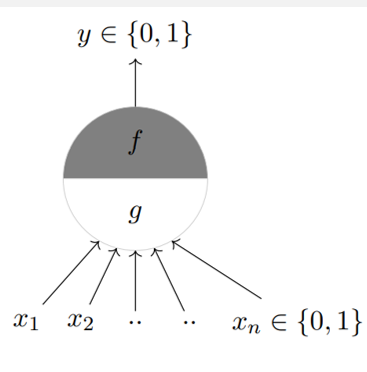

In [1]:
class MP_OR:
    def __init__(self):
        self.theta=1
    def predict(self,x1,x2):
        g=x1+x2
        if g>=self.theta:
            return 1
        else:
            return 0
           
        


In [2]:
orfun=MP_OR()
print(orfun.predict(1,1))

1


In [3]:
orfun=MP_OR()
print(orfun.predict(0,0))

0


## Multilayer Perceptron
An MLP is composed of one (passthrough) input layer, one or more layers of hhidden layers, and one final layer of TLUs called the output layer7). The layers close to the input layer are usually called the lower layer ,
and the ones close to the outputs are usually called the upper layers. Every layer
except the output layer includes a bias neuron and is fully connected to the next la


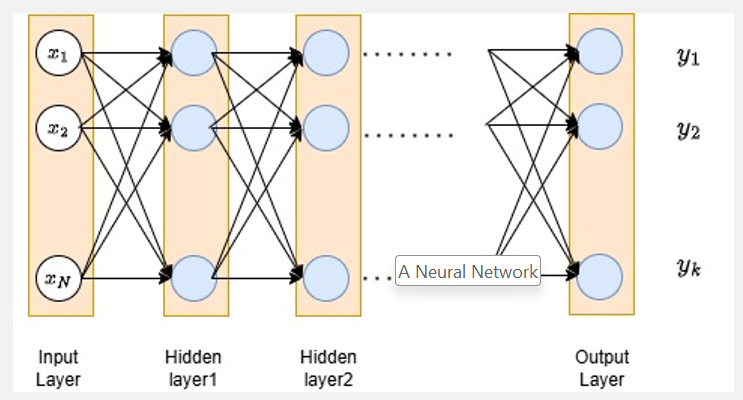yer.

## Implementing MLPs with Keras 
Keras is a high-level Deep Learning API that allows you to easily build, train, evaluate and execute all sorts of neural networks. Its documentation (or specification) is avail‐ able at https://keras.io. The reference implementation is simply called Keras as well, so to avoid any confusion we will call it keras-team (since it is available at https://github.com/keras-team/keras). It was developed by François Chollet as part of a research project12 and released as an open source project in March 2015. It quickly gained popularity owing to its ease-of-use, flexibility and beautiful design. To perform the heavy computations required by neural networks, keras-team relies on a computation backend. 

#### Classification MLPs

MLPs can also be used for classification tasks. For a binary classification problem, you just need a single output neuron using the logistic activation function: the output will be a number between 0 and 1, which you can interpret as the estimated probability of the positive class. Obviously, the estimated probability of the negative class is equal to one minus that number.

MLPs can also easily handle multilabel binary classification tasks. For handwrittn digits recognition, we need 10 output neurons. Each instance can belong only to a single class e.g., classes 0 through 9. then you need to have one output neuron per class, and you should use the somax activation function for the whole output layer. The softmax function will ensure that all the estimated probabilities are between 0 and 1 and that they add up to one (which is required if the classes are exclusive). This is called multiclass classification.


In [4]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
#import cv2
import matplotlib.pyplot as plt

### Building an Image Classifier Using the Sequential API 

we need to load a dataset. We will use Fashion MNIST dataset from tensorflow dataset. 

In [5]:
fashion=keras.datasets.fashion_mnist
(x_train,y_train),(x_test,y_test)=fashion.load_data()

In [6]:
x_train.shape

(60000, 28, 28)

In [7]:
y_train.shape

(60000,)

In [8]:
x_test.shape

(10000, 28, 28)

Scale the pixel intensities down to the 0-1 range by dividing them by 255.0

In [9]:
x_train,x_val=x_train[:10000]/255.0,x_train[10000:]/255.0
y_train,y_val=y_train[:10000],y_train[10000:]

In [10]:
y_train[3]

3

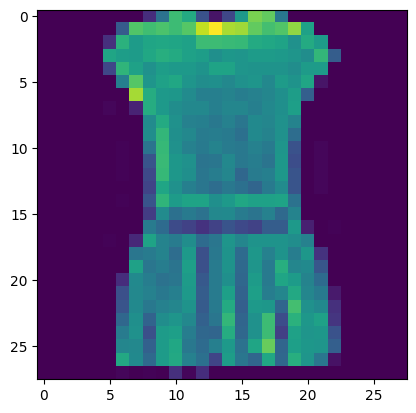

In [11]:
plt.imshow(x_train[3])

In [12]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat","Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [13]:
class_names[y_train[3]]

'Dress'

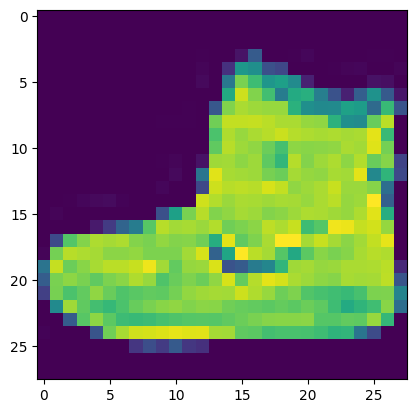

In [14]:
plt.imshow(x_train[0])

Dress


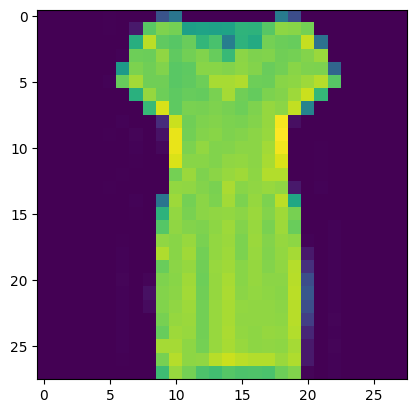

In [15]:
print(class_names[y_train[20]])
plt.imshow(x_train[20])

### Building Block of a neural network
First creates a Sequential model. This is the simplest kind of Keras 
model, for neural networks that are just composed of a single stack of layers, connecte 
sequentially. This is called the sequential API.

In [16]:
model=keras.models.Sequential()

Input data is an image of 2 dimensional. Neural network will take one dimensional input. Next, we required a Flatten layer whose
role is simply to convert each input image into a 1D arra.y

In [17]:
model.add(keras.layers.Flatten(input_shape=[28,28]))

#### Add first hidden layer
Next we add a Dense hidden layer with 300 neurons. It will use the ReLU activation 
function. Each Dense layer manages its own weight matrix, containing all th 
connection weights between the neurons and their inputs.

In [18]:
model.add(keras.layers.Dense(300, activation="relu"))

#### Add second hidden layer
Next we add another Dense hidden layer with 300 neurons. It will use the ReLU activation function. Each Dense layer manages its own weight matrix, containing all the connection weights between the neurons and their inputs.

In [19]:
model.add(keras.layers.Dense(100, activation="relu"))

### Add output layer
Number of class in the dataset is 10. therefore number of neurons at output layer is 10.

In [20]:
model.add(keras.layers.Dense(10,activation='softmax'))

### Model Summary
The model’s summary() method displays all the model’s layers13, including each layer’s 
name (which is automatically generated unless you set it when creating the layer), it 
output shape (None means the batch size can be anything), and its number of parameter .
The summary ends with the total number of parameters, including trainable  nd
non-trainable parameters. Here we only have trainable parameters

In [21]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 784)               0         
                                                                 
 dense (Dense)               (None, 300)               235500    
                                                                 
 dense_1 (Dense)             (None, 100)               30100     
                                                                 
 dense_2 (Dense)             (None, 10)                1010      
                                                                 
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


You can easily get a model’s list of layers, to fetch a layer by its index, or you can fetch 
it by name:

In [22]:
model.layers

In [23]:
model.layers[0]

In [24]:
model.layers[1].name

'dense'

In [25]:
weights,bias=model.layers[1].get_weights()

In [26]:
weights.shape

(784, 300)

In [27]:
bias.shape

(300,)

In [28]:
weights,bias=model.layers[2].get_weights()

In [29]:
bias

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
      dtype=float32)

#### Compiling the Model
After a model is created, you must call its compile() method to specify the loss function and the optimizer to use. Optionally, you can also specify a list of extra metrics to compute during training and evaluation.

In [30]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="sgd",metrics=["accuracy"])

### Training and Evaluating the Model
Now the model is ready to be trained. For this we simply need to call its fit() method. We pass it the input features (X_train) and the target classes (y_train), as well as the number of epochs to train

In [31]:
history = model.fit(x_train, y_train, epochs=30,validation_data=(x_val, y_val))

Epoch 1/30
313/313 [==============================] - 17s 45ms/step - loss: 1.1949 - accuracy: 0.6256 - val_loss: 0.8273 - val_accuracy: 0.7081
Epoch 2/30
313/313 [==============================] - 13s 40ms/step - loss: 0.7249 - accuracy: 0.7536 - val_loss: 0.6815 - val_accuracy: 0.7740
Epoch 3/30
313/313 [==============================] - 11s 34ms/step - loss: 0.6226 - accuracy: 0.7884 - val_loss: 0.6180 - val_accuracy: 0.7913
Epoch 4/30
313/313 [==============================] - 10s 33ms/step - loss: 0.5655 - accuracy: 0.8064 - val_loss: 0.5513 - val_accuracy: 0.8139
Epoch 5/30
313/313 [==============================] - 11s 36ms/step - loss: 0.5354 - accuracy: 0.8146 - val_loss: 0.5360 - val_accuracy: 0.8190
Epoch 6/30
313/313 [==============================] - 12s 39ms/step - loss: 0.5059 - accuracy: 0.8255 - val_loss: 0.5483 - val_accuracy: 0.8007
Epoch 7/30
313/313 [==============================] - 16s 50ms/step - loss: 0.4866 - accuracy: 0.8305 - val_loss: 0.4976 - val_accuracy:

The fit() method returns a History object containing the training parameters (his tory.params), the list of epochs it went through (history.epoch), and most importantly a dictionary (history.history) containing the loss and extra metrics it measured at the end of each epoch on the training set and on the validation set (if any)

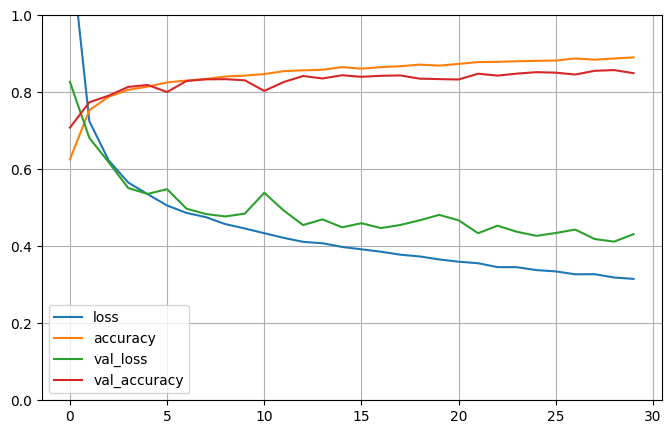

In [32]:
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.gca().set_ylim(0, 1) # set the vertical range to [0-1]
plt.show()

Once you are satisfied with your model’s validation accuracy, you should evaluate it on the test set to estimate the generalization error
before you deploy the model to production. You can easily do this using the evaluate() method

In [33]:
model.evaluate(x_test,y_test)

313/313 [==============================] - 1s 1ms/step - loss: 98.9014 - accuracy: 0.7940


[98.90135955810547, 0.7940000295639038]

### Using the Model to Make Predictions
Next, we can use the model’s predict() method to make predictions on new instances. Since we don’t have actual new instances, we will just use the first 3 instances of the test set:

In [34]:
X_new = x_test[:3]
y_proba = model.predict(X_new)
y_proba.round(2)

1/1 [==============================] - 0s 95ms/step


array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

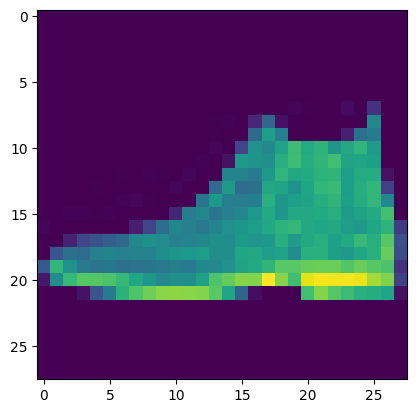

In [35]:
plt.imshow(x_test[0])

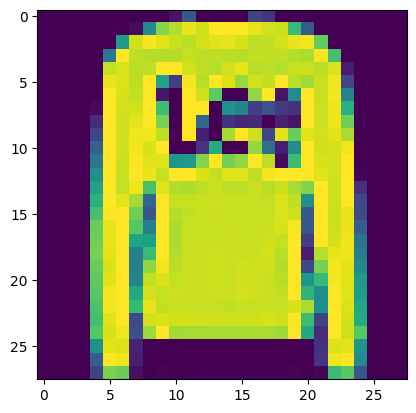

In [36]:
plt.imshow(x_test[1])

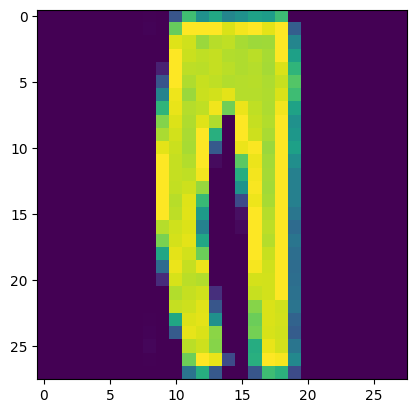

In [37]:
plt.imshow(x_test[2])

## Regression MLPs

MLPs can be used for regression tasks. If you want to predict a single value (e.g., the price of a house given many of its features), then you just need a single output neuron: its output is the predicted value. For multivariate regression (i.e., to predict multiple values at once), you need one output neuron per output dimension. For example, to locate the center of an object on an image, you need to predict 2D coordinates, so you need two output neurons. If you also want to place a bounding box around the object, then you need two more numbers: the width and the height of the object. So you end up with 4 output neurons.

In [59]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [60]:
housing = fetch_california_housing()

In [61]:
X_train_full, X_test, y_train_full, y_test = train_test_split(housing.data, housing.target)
X_train, X_valid, y_train, y_valid = train_test_split(X_train_full, y_train_full)

In [62]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train.shape[1:]

In [87]:
model = keras.models.Sequential([
keras.layers.Dense(30, activation="sigmoid", input_shape=X_train_scaled.shape[1:]),
keras.layers.Dense(1)
])

In [88]:
model.summary()

Model: "sequential_8"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_18 (Dense)            (None, 30)                270       
                                                                 
 dense_19 (Dense)            (None, 1)                 31        
                                                                 
Total params: 301
Trainable params: 301
Non-trainable params: 0
_________________________________________________________________


In [89]:
model.compile(loss="mean_squared_error",optimizer="sgd")

In [91]:
history = model.fit(X_train_scaled,y_train, epochs=50,validation_data=(X_valid_scaled,y_valid))

Epoch 1/50
363/363 [==============================] - 1s 3ms/step - loss: 0.5091 - val_loss: 0.5070
Epoch 2/50
363/363 [==============================] - 1s 2ms/step - loss: 0.5008 - val_loss: 0.4994
Epoch 3/50
363/363 [==============================] - 1s 2ms/step - loss: 0.4956 - val_loss: 0.4987
Epoch 4/50
363/363 [==============================] - 1s 2ms/step - loss: 0.4914 - val_loss: 0.4917
Epoch 5/50
363/363 [==============================] - 1s 2ms/step - loss: 0.4886 - val_loss: 0.4867
Epoch 6/50
363/363 [==============================] - 1s 2ms/step - loss: 0.4867 - val_loss: 0.4843
Epoch 7/50
363/363 [==============================] - 1s 2ms/step - loss: 0.4852 - val_loss: 0.4836
Epoch 8/50
363/363 [==============================] - 1s 2ms/step - loss: 0.4833 - val_loss: 0.4843
Epoch 9/50
363/363 [==============================] - 1s 3ms/step - loss: 0.4822 - val_loss: 0.4813
Epoch 10/50
363/363 [==============================] - 1s 2ms/step - loss: 0.4799 - val_loss: 0.4787

In [92]:
mse_test = model.evaluate(X_test_scaled, y_test)


162/162 [==============================] - 1s 3ms/step - loss: 0.4197


In [93]:
X_new = X_test_scaled[:3] # pretend these are new instances


In [94]:
y_pred = model.predict(X_new)

1/1 [==============================] - 0s 98ms/step


In [95]:
y_pred

array([[1.9421337],
       [2.8248773],
       [1.6532335]], dtype=float32)

# Non Sequential neural network

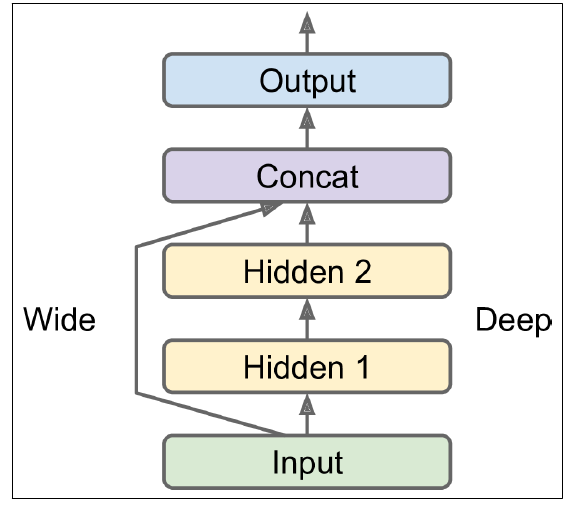

In [97]:
input = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(30, activation="relu")(input)
hidden2 = keras.layers.Dense(30, activation="relu")(hidden1)
concat = keras.layers.Concatenate()([input, hidden2])
output = keras.layers.Dense(1)(concat)
model = keras.models.Model(inputs=[input], outputs=[output])

In [98]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 8)]          0           []                               
                                                                                                  
 dense_20 (Dense)               (None, 30)           270         ['input_1[0][0]']                
                                                                                                  
 dense_21 (Dense)               (None, 30)           930         ['dense_20[0][0]']               
                                                                                                  
 concatenate (Concatenate)      (None, 38)           0           ['input_1[0][0]',                
                                                                  'dense_21[0][0]']           

In [99]:
model.compile(loss="mean_squared_error",optimizer="sgd")

In [100]:
history = model.fit(X_train_scaled,y_train, epochs=50,validation_data=(X_valid_scaled,y_valid))

Epoch 1/50
363/363 [==============================] - 2s 3ms/step - loss: 4.0571 - val_loss: 7.4730
Epoch 2/50
363/363 [==============================] - 1s 3ms/step - loss: 15.9774 - val_loss: 0.5355
Epoch 3/50
363/363 [==============================] - 1s 3ms/step - loss: 0.5418 - val_loss: 0.4646
Epoch 4/50
363/363 [==============================] - 1s 2ms/step - loss: 0.4303 - val_loss: 0.4300
Epoch 5/50
363/363 [==============================] - 1s 2ms/step - loss: 0.4071 - val_loss: 0.4193
Epoch 6/50
363/363 [==============================] - 1s 2ms/step - loss: 0.3916 - val_loss: 0.4058
Epoch 7/50
363/363 [==============================] - 1s 2ms/step - loss: 0.3868 - val_loss: 0.4027
Epoch 8/50
363/363 [==============================] - 1s 2ms/step - loss: 0.4477 - val_loss: 0.3951
Epoch 9/50
363/363 [==============================] - 1s 2ms/step - loss: 0.3675 - val_loss: 0.3783
Epoch 10/50
363/363 [==============================] - 1s 3ms/step - loss: 0.3667 - val_loss: 0.368

In [101]:
mse_test = model.evaluate(X_test_scaled, y_test)


162/162 [==============================] - 0s 2ms/step - loss: 0.3011


In [102]:
X_new = X_test_scaled[:3] # pretend these are new instances
y_pred=model.predict(X_new)
y_pred

1/1 [==============================] - 0s 168ms/step


array([[1.815585 ],
       [2.6947412],
       [1.6072965]], dtype=float32)